In [2]:
# !git clone git@github.com:jukedeck/nottingham-dataset.git
!pip install music21
!pip install tqdm

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [9]:
import json
import music21
import hashlib
from tqdm import tqdm

# ================= 核心配置 =================
CODE_TO_MIDI_OFFSET = 20
TIE_CODE = -1
REST_CODE = 0
UNITS_PER_BAR = 8
NUM_BARS = 4
TOTAL_UNITS = UNITS_PER_BAR * NUM_BARS

def get_chunk_hash(chunk):
    return hashlib.md5(str(chunk).encode('utf-8')).hexdigest()

def process_abc_string(abc_string, seen_hashes):
    """
    解析单个 ABC 字符串，提取 4 小节切片
    """
    valid_chunks = []
    
    # 1. 快速文本预筛 (必须包含 4/4 或 C 拍号)
    # 很多数据是 2/4 或 6/8，解析它们太慢且无用，直接跳过
    if "M:4/4" not in abc_string and "M:C" not in abc_string:
        return []

    try:
        # music21 解析
        # forceSource=True 可能会帮助解析一些只有片段的 string
        score = music21.converter.parse(abc_string, format='abc')
        
        try:
            score = score.expandRepeats()
        except:
            pass

        parts = score.getElementsByClass(music21.stream.Part)
        part = parts[0] if parts else score
        measures = part.makeMeasures()
        measure_list = list(measures.getElementsByClass(music21.stream.Measure))
    except Exception:
        # 解析失败（比如 ABC 格式非法）直接跳过
        return []

    if len(measure_list) < NUM_BARS:
        return []

    # 2. 切片提取
    step = 2
    for i in range(0, len(measure_list) - NUM_BARS + 1, step):
        chunk_measures = measure_list[i : i + NUM_BARS]
        
        # 严格 4/4 检查
        ts = chunk_measures[0].timeSignature
        if ts is None:
            try:
                ts = part.getTimeSignatures().getElementAtOrBefore(chunk_measures[0].offset)
            except:
                pass
        
        if ts is None or ts.ratioString != '4/4':
            continue

        # 网格化
        encoded_chunk = [None] * TOTAL_UNITS
        chunk_start_offset = chunk_measures[0].offset
        is_valid = True
        
        chunk_stream = music21.stream.Stream(chunk_measures).flat
        
        for element in chunk_stream.notesAndRests:
            rel_offset = element.offset - chunk_start_offset
            
            start_idx = int(round(rel_offset * 2))
            duration_units = int(round(element.quarterLength * 2))
            
            # 过滤碎音符 (小于八分音符)
            if duration_units == 0:
                is_valid = False; break
            if start_idx >= TOTAL_UNITS: continue
            
            # 过滤和弦
            if element.isChord:
                is_valid = False; break

            # 过滤重叠
            end_fill_idx = min(start_idx + duration_units, TOTAL_UNITS)
            for k in range(start_idx, end_fill_idx):
                if encoded_chunk[k] is not None:
                    is_valid = False; break
            if not is_valid: break

            # 填值
            if element.isRest:
                val = REST_CODE
                tie_val = REST_CODE
            else:
                val = int(element.pitch.midi) - CODE_TO_MIDI_OFFSET
                tie_val = TIE_CODE
            
            if start_idx < TOTAL_UNITS:
                encoded_chunk[start_idx] = val
            for k in range(start_idx + 1, end_fill_idx):
                encoded_chunk[k] = tie_val

        # 最终检查
        if not is_valid: continue
        if any(x is None for x in encoded_chunk): continue
        if all(x == REST_CODE for x in encoded_chunk): continue

        # 去重
        c_hash = get_chunk_hash(encoded_chunk)
        if c_hash in seen_hashes:
            continue
        
        seen_hashes.add(c_hash)
        valid_chunks.append(encoded_chunk)

    return valid_chunks

def main():
    input_jsonl_path = "melodyhub/validation.jsonl"  # 你的文件路径
    output_jsonl_path = "melodyhub/validation_clean.jsonl"
    
    seen_hashes = set()
    total_extracted = 0
    
    # 获取总行数用于进度条
    total_lines = 0
    with open(input_jsonl_path, 'r', encoding='utf-8') as f:
        for _ in f: total_lines += 1

    print(f"检测到 {total_lines} 行数据，开始处理...")

    with open(input_jsonl_path, 'r', encoding='utf-8') as f_in, \
         open(output_jsonl_path, 'w', encoding='utf-8') as f_out:
        
        for line in tqdm(f_in, total=total_lines):
            try:
                record = json.loads(line)
                task_type = record.get("task", "")
                
                # === 核心策略选择 ===
                sources_to_process = []
                
                # 1. 只需要 Input 的任务
                if task_type == "cataloging":
                    if record.get("input"): sources_to_process.append(record["input"])
                
                # 2. 需要 Input 和 Output 的任务 (Variation)
                elif task_type == "variation":
                    if record.get("input"): sources_to_process.append(record["input"])
                    if record.get("output"): sources_to_process.append(record["output"])
                
                # 3. 其他任务 (Generation, Harmonization, Melodization, Segmentation, Transcription)
                # 这些任务 Output 才是高质量原谱
                else:
                    if record.get("output"): sources_to_process.append(record["output"])

                # === 开始处理选中的内容 ===
                for abc_content in sources_to_process:
                    # 跳过空的或者只有元数据的
                    if not abc_content or len(abc_content) < 10:
                        continue
                        
                    chunks = process_abc_string(abc_content, seen_hashes)
                    
                    for chunk in chunks:
                        out_record = {
                            "melody": chunk,
                            "task": task_type,
                            "src": "melodyhub"
                        }
                        f_out.write(json.dumps(out_record) + "\n")
                        total_extracted += 1

            except Exception as e:
                continue

    print(f"\n处理完成！共提取 {total_extracted} 条高质量旋律。")

if __name__ == "__main__":
    main()

检测到 12701 行数据，开始处理...


  0%|          | 0/12701 [00:00<?, ?it/s]/Users/yiyanliao/anaconda3/envs/music_evolve/lib/python3.12/site-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)
100%|██████████| 12701/12701 [12:43<00:00, 16.63it/s]  


处理完成！共提取 8363 条高质量旋律。


In [4]:
from audio_synth import synthesize_melody
synthesize_melody(
    codes=[51, -1, -1, 47, 49, -1, 49, 47, 51, 49, 51, 54, 59, 56, 54, 52, 51, 47, 47, -1, 49, 42, 46, 49, 54, 56, 58, 54, 52, 49, 46, 49],
    output_path="./test.wav",
    sample_dir="./samples/",
    BPM=167,
    unit_time=180  
)

In [1]:
import json
import music21
import hashlib

# ================= 核心配置 (必须复制一份过来) =================
CODE_TO_MIDI_OFFSET = 20
TIE_CODE = -1
REST_CODE = 0
UNITS_PER_BAR = 8
NUM_BARS = 4
TOTAL_UNITS = UNITS_PER_BAR * NUM_BARS

def get_chunk_hash(chunk):
    return hashlib.md5(str(chunk).encode('utf-8')).hexdigest()

def process_abc_string_pure(abc_string):
    """
    纯函数：解析 ABC 字符串，返回有效片段列表。
    """
    local_chunks = []
    local_seen = set()

    # 1. 快速文本预筛
    if "M:4/4" not in abc_string and "M:C" not in abc_string:
        return []

    try:
        score = music21.converter.parse(abc_string, format='abc')
        try:
            score = score.expandRepeats()
        except:
            pass

        parts = score.getElementsByClass(music21.stream.Part)
        part = parts[0] if parts else score
        measures = part.makeMeasures()
        measure_list = list(measures.getElementsByClass(music21.stream.Measure))
    except Exception:
        return []

    if len(measure_list) < NUM_BARS:
        return []

    # 2. 切片提取
    step = 2
    for i in range(0, len(measure_list) - NUM_BARS + 1, step):
        chunk_measures = measure_list[i : i + NUM_BARS]
        
        # 严格 4/4 检查
        ts = chunk_measures[0].timeSignature
        if ts is None:
            try:
                ts = part.getTimeSignatures().getElementAtOrBefore(chunk_measures[0].offset)
            except:
                pass
        
        if ts is None or ts.ratioString != '4/4':
            continue

        # 网格化
        encoded_chunk = [None] * TOTAL_UNITS
        chunk_start_offset = chunk_measures[0].offset
        is_valid = True
        
        chunk_stream = music21.stream.Stream(chunk_measures).flat
        
        for element in chunk_stream.notesAndRests:
            rel_offset = element.offset - chunk_start_offset
            
            start_idx = int(round(rel_offset * 2))
            duration_units = int(round(element.quarterLength * 2))
            
            if duration_units == 0:
                is_valid = False; break
            if start_idx >= TOTAL_UNITS: continue
            
            if element.isChord:
                is_valid = False; break

            end_fill_idx = min(start_idx + duration_units, TOTAL_UNITS)
            for k in range(start_idx, end_fill_idx):
                if encoded_chunk[k] is not None:
                    is_valid = False; break
            if not is_valid: break

            if element.isRest:
                val = REST_CODE
                tie_val = REST_CODE
            else:
                val = int(element.pitch.midi) - CODE_TO_MIDI_OFFSET
                tie_val = TIE_CODE
            
            if start_idx < TOTAL_UNITS:
                encoded_chunk[start_idx] = val
            for k in range(start_idx + 1, end_fill_idx):
                encoded_chunk[k] = tie_val

        if not is_valid: continue
        if any(x is None for x in encoded_chunk): continue
        if all(x == REST_CODE for x in encoded_chunk): continue

        c_hash = get_chunk_hash(encoded_chunk)
        if c_hash in local_seen:
            continue
        local_seen.add(c_hash)
        
        local_chunks.append(encoded_chunk)

    return local_chunks

def worker_batch_task(lines_batch):
    """
    Worker 任务：接收一批 JSON 字符串，处理并返回结果列表
    """
    batch_results = []
    
    for line in lines_batch:
        try:
            record = json.loads(line)
            task_type = record.get("task", "")
            
            sources_to_process = []
            if task_type == "cataloging":
                if record.get("input"): sources_to_process.append(record["input"])
            elif task_type == "variation":
                if record.get("input"): sources_to_process.append(record["input"])
                if record.get("output"): sources_to_process.append(record["output"])
            else:
                if record.get("output"): sources_to_process.append(record["output"])

            for abc_content in sources_to_process:
                if not abc_content or len(abc_content) < 10:
                    continue
                
                chunks = process_abc_string_pure(abc_content)
                
                for chunk in chunks:
                    batch_results.append({
                        "melody": chunk,
                        "task": task_type,
                        "src": "melodyhub"
                    })
        except Exception:
            continue
            
    return batch_results

In [ ]:
import json
import hashlib
import multiprocessing
import os
from tqdm import tqdm

# ================= 主进程逻辑 =================

def file_chunk_generator(file_path, batch_size=50):
    with open(file_path, 'r', encoding='utf-8') as f:
        batch = []
        for line in f:
            batch.append(line)
            if len(batch) >= batch_size:
                yield batch
                batch = []
        if batch:
            yield batch

def main():
    # 配置路径
    input_jsonl_path = "melodyhub/train.jsonl"
    output_jsonl_path = "melodyhub/train_clean.jsonl"
    
    BATCH_SIZE = 50 
    
    print("正在统计总行数...")
    # 这里加个 try except 防止找不到文件报错
    try:
        total_lines = sum(1 for _ in open(input_jsonl_path, 'r', encoding='utf-8'))
    except FileNotFoundError:
        print(f"❌ 找不到文件: {input_jsonl_path}")
        return

    total_batches = (total_lines // BATCH_SIZE) + 1
    
    cpu_count = multiprocessing.cpu_count()-16
    print(f"检测到 {total_lines} 行数据")
    print(f"启动 {cpu_count} 个 CPU 核心进行并行处理...")

    # 启动进程池
    ctx = multiprocessing.get_context('fork')
    pool = ctx.Pool(processes=cpu_count)
    
    seen_hashes = set()
    total_extracted = 0

    with open(output_jsonl_path, 'w', encoding='utf-8') as f_out:
        
        chunk_gen = file_chunk_generator(input_jsonl_path, BATCH_SIZE)
        
        # 并行计算
        iterator = pool.imap_unordered(worker_batch_task, chunk_gen)
        
        for batch_results in tqdm(iterator, total=total_batches, desc="Processing"):
            for res in batch_results:
                chunk_hash = get_chunk_hash(res['melody'])
                
                if chunk_hash in seen_hashes:
                    continue
                
                seen_hashes.add(chunk_hash)
                f_out.write(json.dumps(res) + "\n")
                total_extracted += 1

    pool.close()
    pool.join()
    
    print(f"\n处理完成！共提取: {total_extracted} 条")

try:
    multiprocessing.set_start_method('fork', force=True)
except RuntimeError:
    pass

if __name__ == "__main__":
    main()

正在统计总行数...
检测到 1055046 行数据
启动 88 个 CPU 核心进行并行处理...


Processing:   0%|          | 0/21101 [00:00<?, ?it/s]/data02/liaoyy/anaconda3/envs/music/lib/python3.12/site-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)
/data02/liaoyy/anaconda3/envs/music/lib/python3.12/site-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)
/data02/liaoyy/anaconda3/envs/music/lib/python3.12/site-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)
/data02/liaoyy/anaconda3/envs/music/lib/python3.12/site-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)
/data02/liaoyy/anaconda3/envs/music/lib/python3.12/

KeyboardInterrupt: 

/data02/liaoyy/anaconda3/envs/music/lib/python3.12/site-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)
/data02/liaoyy/anaconda3/envs/music/lib/python3.12/site-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)


/data02/liaoyy/anaconda3/envs/music/lib/python3.12/site-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)
/data02/liaoyy/anaconda3/envs/music/lib/python3.12/site-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f9e67451280>>
Traceback (most recent call last):
  File "/data02/liaoyy/anaconda3/envs/music/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
KeyboardInterrupt: 
/data02/liaoyy/anaconda3/envs/music/lib/python3.12/site-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilte

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import json
import numpy as np

# ================= 3090 极限配置 =================
# 显存富余策略：先尝试 Batch=4096，如果显存还剩，可以尝试 8192
BATCH_SIZE = 2048       # 暴力拉大，让 GPU 一次吞掉更多数据
EMBEDDING_DIM = 512     # 翻倍，捕捉更细腻的音高语义
HIDDEN_DIM = 2048       # 核心！从 1024 -> 2048，参数量增加 4 倍
NUM_LAYERS = 6          # 增加深度，从 4 -> 6，学习更复杂的乐句结构
DROPOUT = 0.2           # 模型大了，Dropout 保持住
LEARNING_RATE = 0.001   # 大 Batch 通常配合稍大的 LR，0.001 依然安全
EPOCHS = 50              # 多训练几个 Epoch，模型容量大了需要更多时间收敛

DEVICE = torch.device('cuda:4')

print(f"当前配置: Hidden={HIDDEN_DIM}, Layers={NUM_LAYERS}, Batch={BATCH_SIZE}")

# ================= 词表管理 (Vocabulary) =================
class MusicVocab:
    def __init__(self):
        # 预定义特殊符号
        self.pad_token = "<PAD>" # 填充（虽然如果是固定长度可能用不到，但留着是个好习惯）
        self.rest_token = 0      # 原始数据中的休止符
        self.tie_token = -1      # 原始数据中的延音符
        
        # 建立映射表: 原始数值 -> 模型Index
        self.token_to_idx = {}
        self.idx_to_token = {}
        
        # 初始化
        self._add_token(self.pad_token)  # Index 0
        self._add_token(self.rest_token) # Index 1 (对应原始0)
        self._add_token(self.tie_token)  # Index 2 (对应原始-1)
        
        # 预加载 1-100 的音高，确保覆盖 1-88
        # 这样即使训练集没出现某种极低/极高音，模型也不会报错
        for pitch in range(1, 101): 
            self._add_token(pitch)
            
    def _add_token(self, token):
        if token not in self.token_to_idx:
            idx = len(self.token_to_idx)
            self.token_to_idx[token] = idx
            self.idx_to_token[idx] = token
            
    def encode(self, seq):
        """把原始旋律数组转为 Index 数组"""
        return [self.token_to_idx.get(x, self.token_to_idx[self.rest_token]) for x in seq]

    def decode(self, idx_seq):
        """把 Index 数组转回原始旋律"""
        return [self.idx_to_token.get(x, 0) for x in idx_seq]
    
    def __len__(self):
        return len(self.token_to_idx)

# 初始化并锁定词表
vocab = MusicVocab()
print(f"词表大小: {len(vocab)} (包含 PAD, Rest, Tie 和 1-100 音高)")

当前配置: Hidden=2048, Layers=6, Batch=2048
词表大小: 103 (包含 PAD, Rest, Tie 和 1-100 音高)


In [ ]:
from tqdm import tqdm
import random
import torch

class MusicAugmentor:
    def __init__(self, vocab):
        self.vocab = vocab
        # 预计算音高范围 (排除 PAD, Rest, Tie)
        self.pitch_tokens = [k for k, v in vocab.token_to_idx.items() 
                             if isinstance(k, int) and k > 0]
        self.min_pitch = min(self.pitch_tokens)
        self.max_pitch = max(self.pitch_tokens)
        
        self.rest_idx = vocab.token_to_idx[vocab.rest_token]
        self.tie_idx = vocab.token_to_idx[vocab.tie_token]
        self.pad_idx = vocab.token_to_idx[vocab.pad_token]

    def pitch_shift(self, seq_tensor):
        """
        音高平移: 随机上下平移 [-5, +5] 个半音
        """
        if random.random() < 0.5: return seq_tensor
        
        shift = random.randint(-5, 5)
        if shift == 0: return seq_tensor
        
        # 只对音符进行平移 (排除 Rest, Tie, Pad)
        # 假设 0,1,2 是特殊符号
        mask = (seq_tensor > 2) 
        
        out = seq_tensor.clone()
        out[mask] += shift
        
        # 边界检查: 如果平移后超出词表范围，回滚
        if (out[mask] < 3).any() or (out[mask] >= len(self.vocab)).any():
            return seq_tensor
            
        return out

    def time_shift(self, seq_tensor):
        """
        时间平移: 循环移动序列
        """
        if random.random() < 0.3: return seq_tensor
        
        shift = random.randint(1, len(seq_tensor) - 1)
        return torch.roll(seq_tensor, shifts=shift, dims=0)

    def duration_modification(self, seq_tensor):
        """
        时值扰动: 随机把 Tie 变成 Rest (断奏)
        """
        if random.random() < 0.3: return seq_tensor
        
        # 找到所有 Tie 的位置
        tie_mask = (seq_tensor == self.tie_idx)
        
        # 随机生成掩码，以 10% 概率把 Tie 变成 Rest
        noise = torch.rand_like(seq_tensor.float())
        change_mask = tie_mask & (noise < 0.1)
        
        out = seq_tensor.clone()
        out[change_mask] = self.rest_idx
        return out

    def __call__(self, seq_tensor):
        # 串联增强
        seq = self.pitch_shift(seq_tensor)
        seq = self.time_shift(seq)
        seq = self.duration_modification(seq)
        return seq

class InMemoryDataset(Dataset):
    def __init__(self, jsonl_path, vocab, augment=False):
        self.vocab = vocab
        self.augment = augment
        self.augmentor = MusicAugmentor(vocab) if augment else None
        
        data_list = []
        
        print(f"正在加载 {jsonl_path} 到内存 (Augment={augment})...")
        with open(jsonl_path, 'r', encoding='utf-8') as f:
            for line in tqdm(f):
                try:
                    record = json.loads(line)
                    melody = record['melody']
                    if len(melody) < 2: continue
                    encoded = self.vocab.encode(melody)
                    data_list.append(encoded)
                except: continue
        
        # 关键优化：直接转成一个巨大的 LongTensor
        self.data_tensor = torch.tensor(data_list, dtype=torch.long)
        print(f"数据加载完成，Tensor 形状: {self.data_tensor.shape}")

    def __len__(self):
        return len(self.data_tensor)

    def __getitem__(self, idx):
        # 极速读取
        full_seq = self.data_tensor[idx]
        
        # 实时增强
        if self.augment:
            full_seq = self.augmentor(full_seq)
            
        return full_seq[:-1], full_seq[1:]

# 重新加载数据
train_dataset = InMemoryDataset('melodyhub/train_clean.jsonl', vocab, augment=True)
val_dataset = InMemoryDataset('melodyhub/validation_clean.jsonl', vocab, augment=False)

# 这里 num_workers 可以设为 4 了，利用多核加速数据增强
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

正在加载 melodyhub/train_clean.jsonl 到内存...


0it [00:00, ?it/s]

322484it [00:05, 56940.80it/s]


数据加载完成，Tensor 形状: torch.Size([322484, 32])
正在加载 melodyhub/validation_clean.jsonl 到内存...


8363it [00:00, 44107.93it/s]


数据加载完成，Tensor 形状: torch.Size([8363, 32])


In [4]:
class MelodyLSTM_God(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, dropout):
        super(MelodyLSTM_God, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # 你的 3090 喜欢大矩阵运算
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        # LayerNorm 有助于大模型收敛
        self.ln = nn.LayerNorm(hidden_dim)
        self.dropout_layer = nn.Dropout(dropout)
        
        # 映射回词表
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x):
        embeds = self.embedding(x)
        lstm_out, _ = self.lstm(embeds)
        
        # 加入 LayerNorm 和 Dropout
        out = self.ln(lstm_out)
        out = self.dropout_layer(out)
        
        logits = self.fc(out)
        return logits

model = MelodyLSTM_God(len(vocab), EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(DEVICE)

# 编译模型！PyTorch 2.0 的黑科技
# 这一步在 3090 上非常关键，它可以把 LSTM 的循环操作融合，极大提升利用率
try:
    model = torch.compile(model)
    print("✅ PyTorch 2.0 Compiler: Enabled (速度起飞准备)")
except Exception as e:
    print(f"⚠️ 无法启用 torch.compile: {e}")

# 计算参数量
total_params = sum(p.numel() for p in model.parameters())
print(f"模型参数量: {total_params / 1_000_000:.2f} M ")

✅ PyTorch 2.0 Compiler: Enabled (速度起飞准备)
模型参数量: 189.11 M 


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
scaler = GradScaler()

def evaluate(model, val_loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs.reshape(-1, len(vocab)), targets.reshape(-1))
            total_loss += loss.item()
    return total_loss / len(val_loader)

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    start_time = time.time()
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for inputs, targets in pbar:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer.zero_grad(set_to_none=True) # set_to_none 比 zero_grad 稍微快一点点
        
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs.reshape(-1, len(vocab)), targets.reshape(-1))
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = evaluate(model, val_loader, criterion)
    scheduler.step(avg_val_loss)
    
    current_lr = optimizer.param_groups[0]['lr']
    dt = time.time() - start_time
    print(f"Epoch {epoch+1} | Time: {dt:.1f}s | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")
    
    # 保存检查点
    torch.save(model.state_dict(), "lstm.pth")

print("训练结束！")

/tmp/ipykernel_2886282/3154252857.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


🚀 全功率训练开始...


Epoch 1/50:   0%|          | 0/158 [00:00<?, ?it/s]

/tmp/ipykernel_2886282/3154252857.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/50:   1%|          | 1/158 [00:07<18:31,  7.08s/it, loss=4.8637]/tmp/ipykernel_2886282/3154252857.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/50: 100%|██████████| 158/158 [03:21<00:00,  1.27s/it, loss=2.0444]
/tmp/ipykernel_2886282/3154252857.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1 | Time: 203.1s | Train Loss: 2.5057 | Val Loss: 2.0505 | LR: 0.001000


...

Epoch 26 | Time: 204.2s | Train Loss: 0.5664 | Val Loss: 0.8381 | LR: 0.000500


Epoch 27/50: 100%|██████████| 158/158 [03:23<00:00,  1.28s/it, loss=0.5461]


Epoch 27 | Time: 204.8s | Train Loss: 0.5342 | Val Loss: 0.8436 | LR: 0.000500


Epoch 28/50:   3%|▎         | 4/158 [00:06<04:06,  1.60s/it, loss=0.5082]


KeyboardInterrupt: 

In [2]:
import random
import numpy as np
from typing import List, Tuple
import torch
import torch.nn as nn
import math

# ================= LSTM 模型配置 (必须与训练时一致) =================
MODEL_PATH = "lstm_24.pth"  # 请确保这个文件存在
BATCH_SIZE = 2048       # 暴力拉大，让 GPU 一次吞掉更多数据
EMBEDDING_DIM = 512     # 翻倍，捕捉更细腻的音高语义
HIDDEN_DIM = 2048       # 核心！从 1024 -> 2048，参数量增加 4 倍
NUM_LAYERS = 6          # 增加深度，从 4 -> 6，学习更复杂的乐句结构
DROPOUT = 0.2           # 模型大了，Dropout 保持住
LEARNING_RATE = 0.001   # 大 Batch 通常配合稍大的 LR，0.001 依然安全
EPOCHS = 50              # 多训练几个 Epoch，模型容量大了需要更多时间收敛
DEVICE = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')

# ================= 1. 定义词表类 (与训练代码一致) =================
class MusicVocab:
    def __init__(self):
        # 预定义特殊符号
        self.pad_token = "<PAD>" # 填充（虽然如果是固定长度可能用不到，但留着是个好习惯）
        self.rest_token = 0      # 原始数据中的休止符
        self.tie_token = -1      # 原始数据中的延音符
        
        # 建立映射表: 原始数值 -> 模型Index
        self.token_to_idx = {}
        self.idx_to_token = {}
        
        # 初始化
        self._add_token(self.pad_token)  # Index 0
        self._add_token(self.rest_token) # Index 1 (对应原始0)
        self._add_token(self.tie_token)  # Index 2 (对应原始-1)
        
        # 预加载 1-100 的音高，确保覆盖 1-88
        # 这样即使训练集没出现某种极低/极高音，模型也不会报错
        for pitch in range(1, 101): 
            self._add_token(pitch)
            
    def _add_token(self, token):
        if token not in self.token_to_idx:
            idx = len(self.token_to_idx)
            self.token_to_idx[token] = idx
            self.idx_to_token[idx] = token
            
    def encode(self, seq):
        """把原始旋律数组转为 Index 数组"""
        return [self.token_to_idx.get(x, self.token_to_idx[self.rest_token]) for x in seq]

    def decode(self, idx_seq):
        """把 Index 数组转回原始旋律"""
        return [self.idx_to_token.get(x, 0) for x in idx_seq]
    
    def __len__(self):
        return len(self.token_to_idx)

# ================= 2. 定义模型类 (与训练代码一致) =================
class MelodyLSTM_God(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, dropout):
        super(MelodyLSTM_God, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # 你的 3090 喜欢大矩阵运算
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        # LayerNorm 有助于大模型收敛
        self.ln = nn.LayerNorm(hidden_dim)
        self.dropout_layer = nn.Dropout(dropout)
        
        # 映射回词表
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x):
        embeds = self.embedding(x)
        lstm_out, _ = self.lstm(embeds)
        
        # 加入 LayerNorm 和 Dropout
        out = self.ln(lstm_out)
        out = self.dropout_layer(out)
        
        logits = self.fc(out)
        return logits

# ================= 3. 全局加载模型 (只加载一次) =================
print(f"正在加载 LSTM 评分模型: {MODEL_PATH} ...")
try:
    # 初始化词表
    vocab = MusicVocab()
    
    # 初始化模型结构
    model = MelodyLSTM_God(len(vocab), EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
    
    # 加载权重
    state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
    
    # ================= 核心修复代码开始 =================
    # 检测是否包含 torch.compile 产生的 "_orig_mod." 前缀
    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith("_orig_mod."):
            # 去掉前缀 "_orig_mod." (长度为10)
            name = k[10:] 
            new_state_dict[name] = v
        else:
            new_state_dict[k] = v
    # ================= 核心修复代码结束 =================
    
    # 加载清洗后的字典
    model.load_state_dict(new_state_dict)
    
    model.to(DEVICE)
    model.eval() # 开启评估模式 (关闭 Dropout)
    print("模型加载成功！")
    
except Exception as e:
    print(f"严重错误: 无法加载模型 ({e})。请确保 {MODEL_PATH} 存在且配置与训练时一致。")
    model = None


# ================= 4. LSTM 适应度函数 =================

def fitness(mel: List[int]) -> float:
    """
    基于 LSTM 模型的适应度函数。
    计算旋律在模型下的生成概率 (Likelihood)。
    
    逻辑:
    1. 输入 [n0, n1, ..., n30]
    2. 预测 [n1, n2, ..., n31]
    3. 计算 CrossEntropyLoss (负对数似然)
    4. 将 Loss 转换为 0~1 的分数。Loss 越低 (越符合训练数据分布)，分数越高。
    """
    # 基础检查
    if not mel or len(mel) < 2:
        return 0.0
    
    # 如果模型加载失败，返回默认分 (防止程序崩溃)
    if model is None:
        return 0.0

    # 1. 编码数据
    # 注意：我们的 Vocab 已经处理了 0, -1, 33-59 等所有情况
    encoded_seq = vocab.encode(mel)
    
    # 转为 Tensor (Batch Size = 1)
    # shape: (1, 32)
    seq_tensor = torch.tensor(encoded_seq, dtype=torch.long).unsqueeze(0).to(DEVICE)
    
    # 2. 准备错位输入
    # Input:  0 ~ 30
    # Target: 1 ~ 31
    inputs = seq_tensor[:, :-1]
    targets = seq_tensor[:, 1:]
    
    # 3. 模型推理
    with torch.no_grad():
        logits = model(inputs) # (1, 31, vocab_size)
        
        # 计算 Loss
        # reshape 展平以适配 CrossEntropy
        loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(logits.reshape(-1, len(vocab)), targets.reshape(-1))
        
        nll = loss.item()
    
    # 4. 分数转换
    # NLL (Negative Log Likelihood) 通常在 0.0 (完美) 到 10.0+ (完全随机) 之间
    # 训练好的模型 NLL 可能在 0.5 ~ 2.0 之间
    # 转换公式：Score = exp(-NLL)
    # 当 Loss = 0, Score = 1.0
    # 当 Loss = 1, Score = 0.36
    # 当 Loss = 5, Score = 0.006
    final_score = math.exp(-nll)
    
    return round(final_score, 6)

正在加载 LSTM 评分模型: lstm_24.pth ...
模型加载成功！


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import json
from tqdm.notebook import tqdm
import torch.nn.functional as F

# ================= 辅助函数：批量计算分数 (极大加速) =================
def compute_scores_from_file(file_path, batch_size=2048, desc="Processing"):
    """读取 JSONL 文件并批量计算 Fitness Score"""
    scores = []
    batch_data = []
    
    # 1. 读取所有数据
    print(f"Reading {file_path}...")
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
    print(f"Total lines: {len(lines)}. Start inference...")
    
    # 2. 批量推理
    model.eval()
    with torch.no_grad():
        for i in tqdm(range(0, len(lines), batch_size), desc=desc):
            # 准备一个 Batch 的数据
            batch_lines = lines[i : i + batch_size]
            batch_seqs = []
            
            for line in batch_lines:
                try:
                    rec = json.loads(line)
                    mel = rec['melody']
                    if len(mel) == 32: # 确保长度对齐
                        encoded = vocab.encode(mel)
                        batch_seqs.append(encoded)
                except: continue
            
            if not batch_seqs: continue
            
            # 转 Tensor
            # Shape: (Batch, 32)
            seq_tensor = torch.tensor(batch_seqs, dtype=torch.long).to(DEVICE)
            
            # 错位预测
            inputs = seq_tensor[:, :-1]  # (Batch, 31)
            targets = seq_tensor[:, 1:]  # (Batch, 31)
            
            # Forward
            logits = model(inputs) # (Batch, 31, Vocab)
            
            # 计算 Loss (reduction='none' 得到每个样本的 Loss)
            # Permute logits to (Batch, Vocab, Seq_len) for CrossEntropy
            loss = F.cross_entropy(logits.permute(0, 2, 1), targets, reduction='none')
            # loss shape: (Batch, 31)
            
            # 对每个样本求平均 Loss
            avg_loss_per_sample = loss.mean(dim=1) # (Batch, )
            
            # 转换为 Score: exp(-loss)
            batch_scores = torch.exp(-avg_loss_per_sample).cpu().numpy()
            scores.extend(batch_scores)
            
    return scores

# ================= 辅助函数：生成 10000 条随机旋律 =================
def generate_random_batch_scores(num_samples=10000, batch_size=2048):
    """生成随机噪声旋律并计算分数"""
    scores = []
    print(f"Generating {num_samples} random melodies and scoring...")
    
    model.eval()
    with torch.no_grad():
        for i in tqdm(range(0, num_samples, batch_size), desc="Random Noise"):
            current_batch_size = min(batch_size, num_samples - i)
            
            # 快速生成随机数据 (模拟 random_melody 的逻辑)
            # 范围: 33-59 (音符), 0 (休止), -1 (延音)
            # 这里简单做均匀分布，实际上 random_melody 可能有概率偏好，但作为对照组足够了
            # 我们生成 33~59 的音符，混入一些 0 和 -1
            # 简化：直接在词表中随机采样 (除了 PAD)
            
            # 生成随机索引 (1 ~ len(vocab)-1)
            # 0 是 PAD，1 是 Rest, 2 是 Tie, 3... 是音高
            rand_tensor = torch.randint(1, len(vocab), (current_batch_size, 32)).to(DEVICE)
            
            inputs = rand_tensor[:, :-1]
            targets = rand_tensor[:, 1:]
            
            logits = model(inputs)
            loss = F.cross_entropy(logits.permute(0, 2, 1), targets, reduction='none')
            avg_loss = loss.mean(dim=1)
            batch_scores = torch.exp(-avg_loss).cpu().numpy()
            scores.extend(batch_scores)
            
    return scores

Reading melodyhub/train_clean.jsonl...
Total lines: 322484. Start inference...


Scoring Train:   0%|          | 0/79 [00:00<?, ?it/s]

Reading melodyhub/validation_clean.jsonl...
Total lines: 8363. Start inference...


Scoring Val:   0%|          | 0/3 [00:00<?, ?it/s]

Generating 10000 random melodies and scoring...


Random Noise:   0%|          | 0/5 [00:00<?, ?it/s]

Train Set Size: 322484
Validation Set Size: 8363
------------------------------
Train Avg Score:  0.6218
Val Avg Score:    0.5006
Random Avg Score: 0.0000


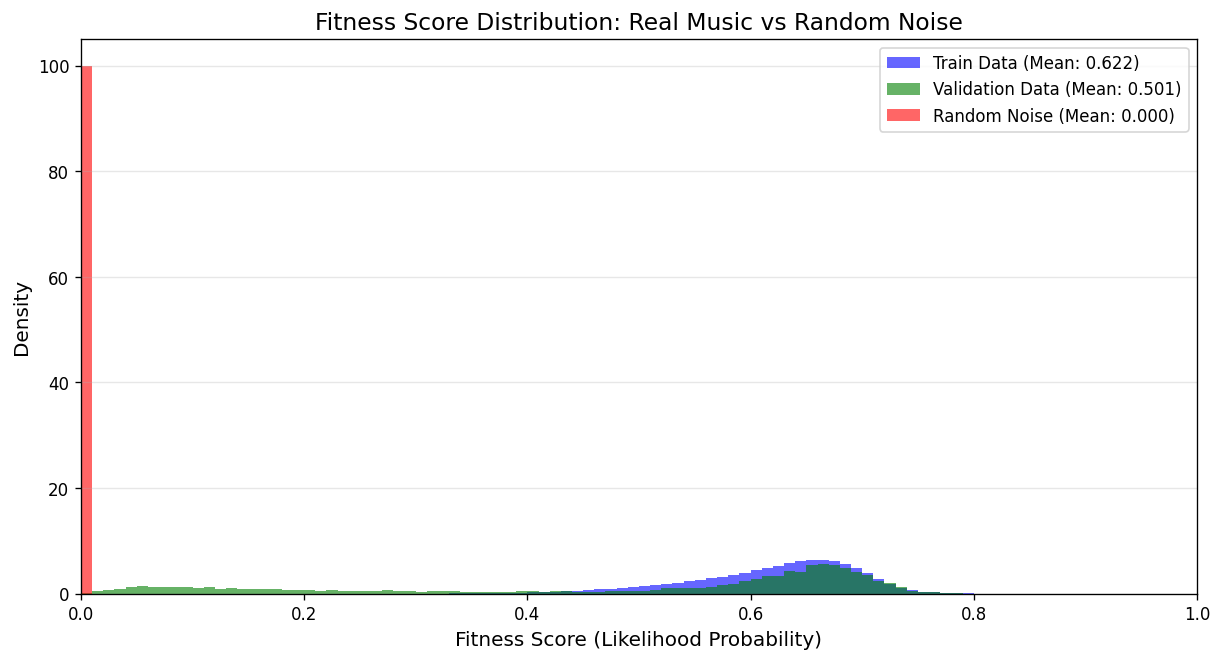

In [5]:
# 1. 计算三个数据集的分数
# 请确保路径正确
train_scores = compute_scores_from_file('melodyhub/train_clean.jsonl', batch_size=4096, desc="Scoring Train")
val_scores = compute_scores_from_file('melodyhub/validation_clean.jsonl', batch_size=4096, desc="Scoring Val")
random_scores = generate_random_batch_scores(num_samples=10000)

# 2. 绘制直方图
plt.figure(figsize=(12, 6), dpi=120)

# 设置 Bin 的数量
bins = 100
alpha = 0.6

# 绘制 Train (蓝色)
plt.hist(train_scores, bins=bins, range=(0, 1), density=True, alpha=alpha, color='blue', label=f'Train Data (Mean: {np.mean(train_scores):.3f})')

# 绘制 Validation (绿色)
plt.hist(val_scores, bins=bins, range=(0, 1), density=True, alpha=alpha, color='green', label=f'Validation Data (Mean: {np.mean(val_scores):.3f})')

# 绘制 Random (红色)
plt.hist(random_scores, bins=bins, range=(0, 1), density=True, alpha=alpha, color='red', label=f'Random Noise (Mean: {np.mean(random_scores):.3f})')


# 图表装饰
plt.title('Fitness Score Distribution: Real Music vs Random Noise', fontsize=14)
plt.xlabel('Fitness Score (Likelihood Probability)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.xlim(0, 1.0)

# 显示统计信息
print(f"Train Set Size: {len(train_scores)}")
print(f"Validation Set Size: {len(val_scores)}")
print("-" * 30)
print(f"Train Avg Score:  {np.mean(train_scores):.4f}")
print(f"Val Avg Score:    {np.mean(val_scores):.4f}")
print(f"Random Avg Score: {np.mean(random_scores):.4f}")

plt.show()